# Percentile

While a **percentage** tells you how you did compared to the total possible score (part-to-whole), a **percentile** tells you how you did *compared to everyone else* (rank).

A percentile indicates the value below which a certain percentage of the data falls. If you take a standardized test and score in the **90th percentile**, it does not mean you answered 90% of the questions correctly. It means your score was higher than 90% of the other people who took the test.

Percentiles are incredibly useful because they give meaning to a raw number. A score of 1200 on an exam means nothing until you know that it places you in the 85th percentile.

## Quartiles: The Most Important Percentiles

In descriptive statistics, we often divide data into four equal chunks to quickly understand its spread. These specific percentiles are called **Quartiles**:

* **1st Quartile ($Q_1$):** The 25th percentile. 25% of the data falls below this point.
* **2nd Quartile ($Q_2$):** The 50th percentile. This is exactly the **Median**. Half the data is below, half is above.
* **3rd Quartile ($Q_3$):** The 75th percentile. 75% of the data falls below this point.

The distance between $Q_1$ and $Q_3$ is called the **Interquartile Range (IQR)**, which represents the middle 50% of your data. It is a fantastic measure of variability because it completely ignores extreme outliers at the very top and bottom.

---

## Visualizing Percentiles

### The Normal Distribution Curve

If your data follows a normal, symmetrical bell curve, percentiles map perfectly to standard deviations.

{/* Reason: Showing how percentages of the population fall into different sections of a normal curve is essential for understanding how percentiles map to real-world distributions. */}

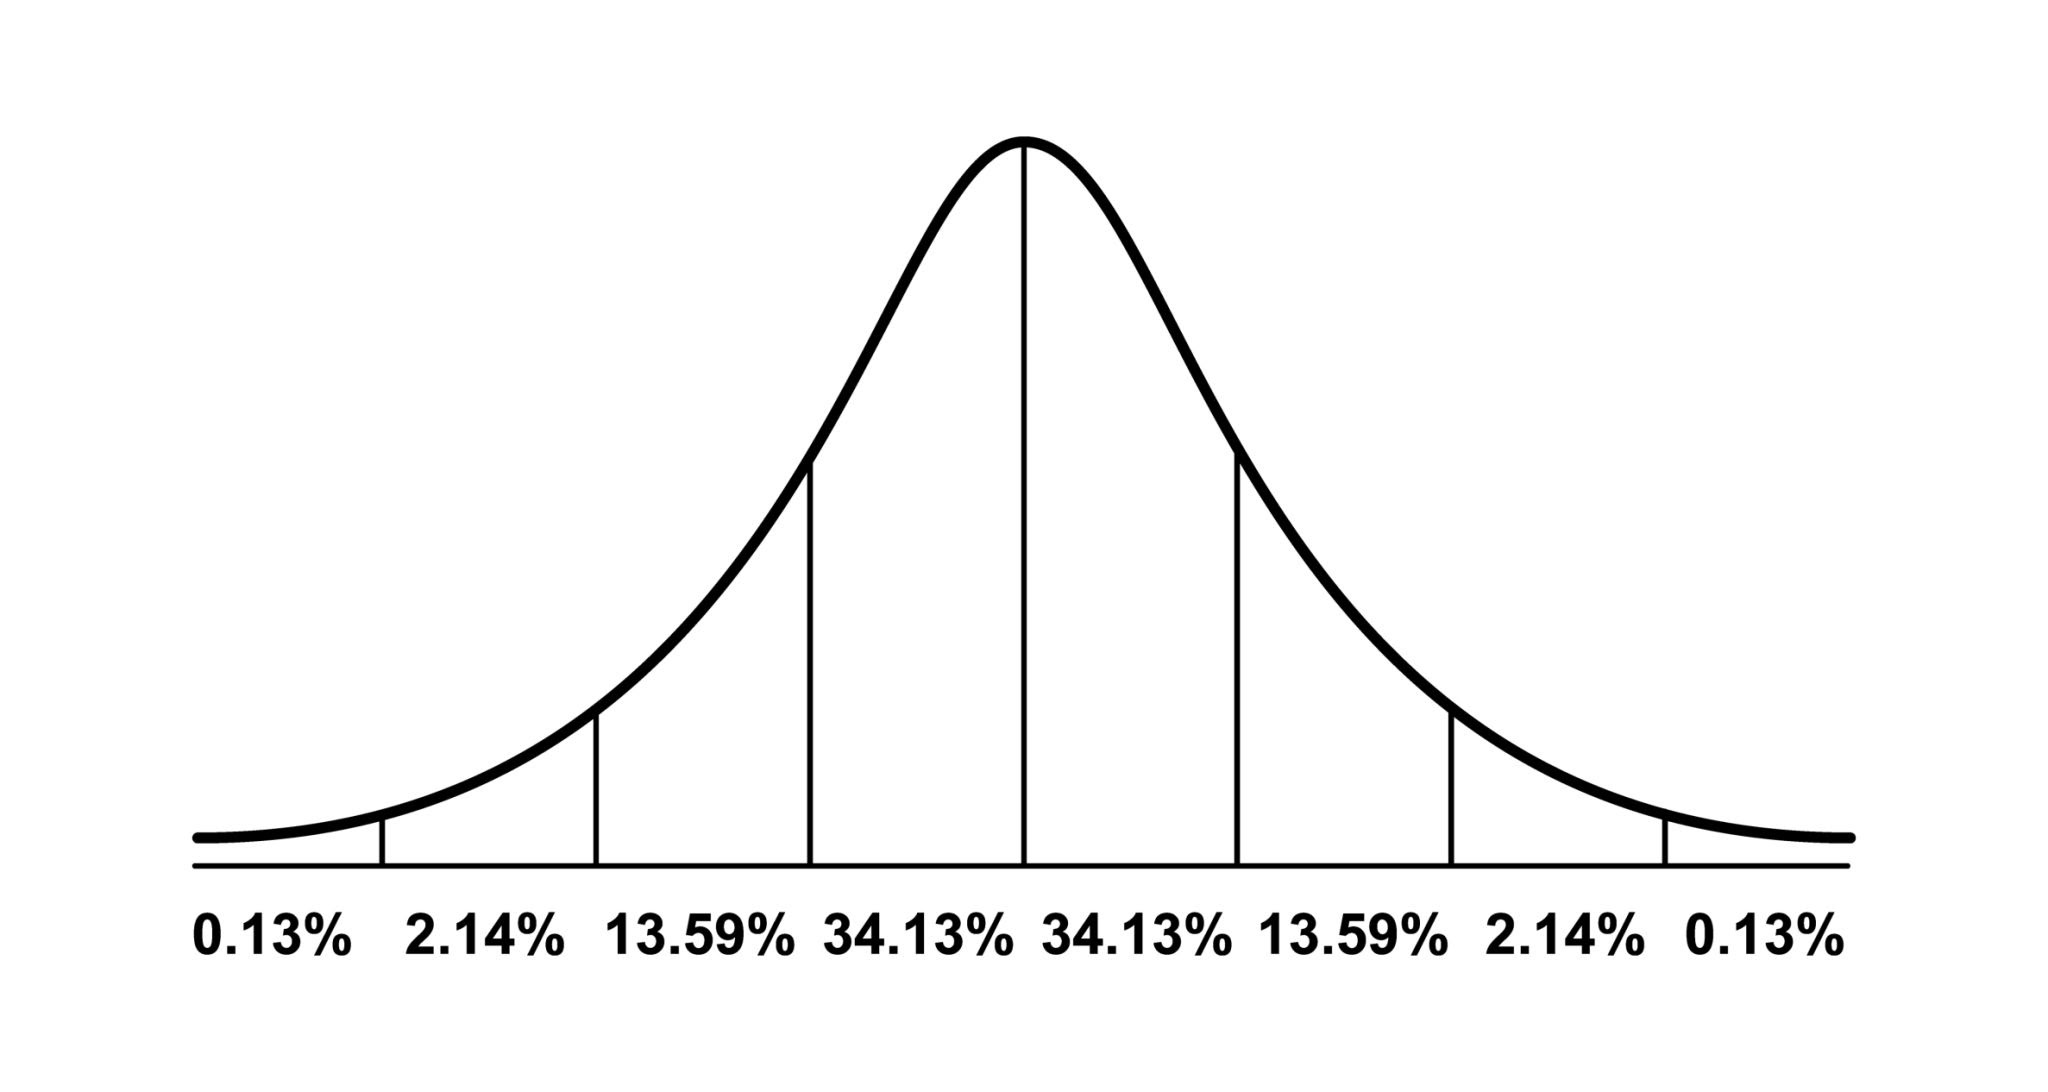

<center>Percentiles on a normal distribution. Source: Drypsiak / Getty Images</center>

In a perfectly normal distribution, the 50th percentile is right in the middle (the peak). As you move to the extreme edges (the "tails"), it takes a much larger change in the raw value to move up or down a single percentile, because very few people score in those extreme ranges.

### The Box Plot (Box-and-Whisker Plot)

Statisticians use a specific chart called a **Box Plot** to visualize percentiles and quartiles at a glance.

* The "box" represents the middle 50% of the data (the IQR, from the 25th to the 75th percentile).
* The line inside the box is the median (50th percentile).
* The "whiskers" stretch out to the minimum and maximum values, excluding statistical outliers (which are plotted as individual dots).

{/* Reason: An interactive box plot perfectly demonstrates how changing raw data points dynamically shifts the quartiles (percentiles) and the median. */}

In this Python script you can run in a Google Colab notebook to see exactly how percentiles, quartiles, and outliers are calculated and visualized.

This Colab engine uses `seaborn` and `matplotlib` to draw a box plot directly over the raw data points. It gives you a slider to control one specific "adjustable point." As you drag this point, you will see the quartiles shift, and if you drag it far enough, you will see it cross the "fence" to mathematically become an outlier.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

# A fixed base dataset of normal values
base_data = [12, 15, 16, 18, 20, 22, 24, 25, 28]

def update_boxplot(adjustable_point):
    """
    Recalculates quartiles and redraws the box plot dynamically
    as the user moves the adjustable point.
    """
    # Combine the base dataset with our dynamic point
    data = np.array(base_data + [adjustable_point])

    # Calculate exact percentiles (Quartiles)
    q1 = np.percentile(data, 25)
    median = np.percentile(data, 50)
    q3 = np.percentile(data, 75)

    # Calculate Interquartile Range (IQR) and Outlier Fences
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Set up the plot
    fig, ax = plt.subplots(figsize=(12, 5))

    # 1. Draw the box plot (the blue box and whiskers)
    sns.boxplot(x=data, color='#3498db', ax=ax, width=0.4, fliersize=0)

    # 2. Draw the raw data points underneath to show what builds the box
    sns.stripplot(x=data, color='black', size=7, alpha=0.5, jitter=False, ax=ax)

    # 3. Highlight the specific point the user is controlling
    ax.scatter([adjustable_point], [0], color='#e74c3c', s=200, zorder=10,
               edgecolor='black', label='Your Adjustable Point')

    # 4. Draw explicit lines showing the mathematical boundaries
    ax.axvline(q1, color='#2ecc71', linestyle='--', linewidth=2, label=f'Q1 (25th %): {q1:.1f}')
    ax.axvline(median, color='#f1c40f', linestyle='-', linewidth=3, label=f'Median: {median:.1f}')
    ax.axvline(q3, color='#9b59b6', linestyle='--', linewidth=2, label=f'Q3 (75th %): {q3:.1f}')

    # Show the invisible fences that determine outliers
    ax.axvline(upper_bound, color='#c0392b', linestyle=':', linewidth=2, label=f'Upper Fence (1.5x IQR)')
    ax.axvline(lower_bound, color='#c0392b', linestyle=':', linewidth=2, label=f'Lower Fence (1.5x IQR)')

    # Formatting the chart
    ax.set_xlim(0, 60)
    ax.set_yticks([]) # Hide the y-axis (only 1D spread matters)
    ax.set_xlabel("Data Value", fontsize=12)
    ax.set_title("Interactive Box Plot & Quartile Explorer", fontsize=15, pad=15)

    # Place legend outside the plot
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1))

    plt.tight_layout()
    plt.show()

print("Drag the slider to move the red data point.")
print("Watch how the blue box (IQR) stretches, and notice what happens when the point crosses the red dotted fence.")

# Create an interactive slider for the user
slider = widgets.FloatSlider(
    value=20,
    min=0,
    max=60,
    step=1,
    description='Red Point:',
    continuous_update=True,
    layout=widgets.Layout(width='500px')
)

# Bind the slider to the plot function
widgets.interact(update_boxplot, adjustable_point=slider);

Drag the slider to move the red data point.
Watch how the blue box (IQR) stretches, and notice what happens when the point crosses the red dotted fence.


interactive(children=(FloatSlider(value=20.0, description='Red Point:', layout=Layout(width='500px'), max=60.0…

### What to Look For in the Colab Notebook

Once you execute the cell, use the slider to drag the large red dot across the number line.

* **The Middle 50%:** The blue box represents the Interquartile Range (IQR). This is where the core of your data lives. As you move the red point around inside the box, notice how the green (Q1) and purple (Q3) lines slightly adjust to accommodate it.
* **The Median's Resistance:** Drag the red point wildly from left to right. Notice how the yellow Median line barely moves, while a standard "mean" (average) would swing dramatically. This is why percentiles are incredibly robust against extreme data.
* **Breaking the Outlier Fence:** Watch the red dotted line (the Upper Fence). In statistics, any point that falls more than 1.5x the IQR above Q3 is mathematically defined as an outlier. Drag your red dot to a value like `50`. You will see the black whisker stop at the highest "normal" value, leaving your red dot stranded as a detached outlier.

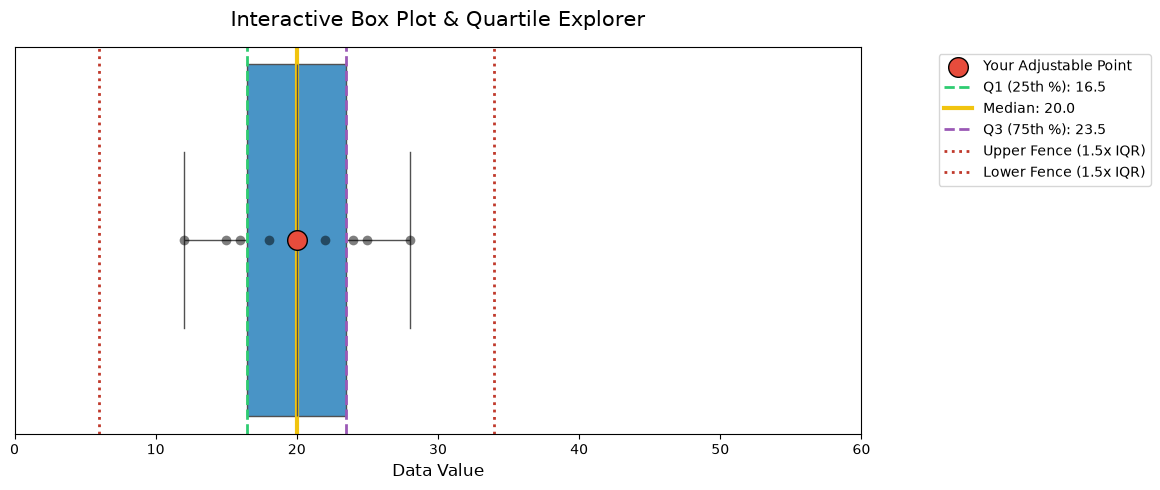

In [2]:
# --- static render for the published website ---
# The sliders above need a live Python kernel. This cell renders the same chart at
# the sliders' default values so the figure is always visible on the website.
update_boxplot(adjustable_point=20)
